In [10]:
import os
print("Ti trovi nella cartella:", os.getcwd())

Ti trovi nella cartella: /home/michele/EsempiGeant4_basic/radionuclide/scripts


/tmp/ipykernel_38708/2642841376.py:37: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


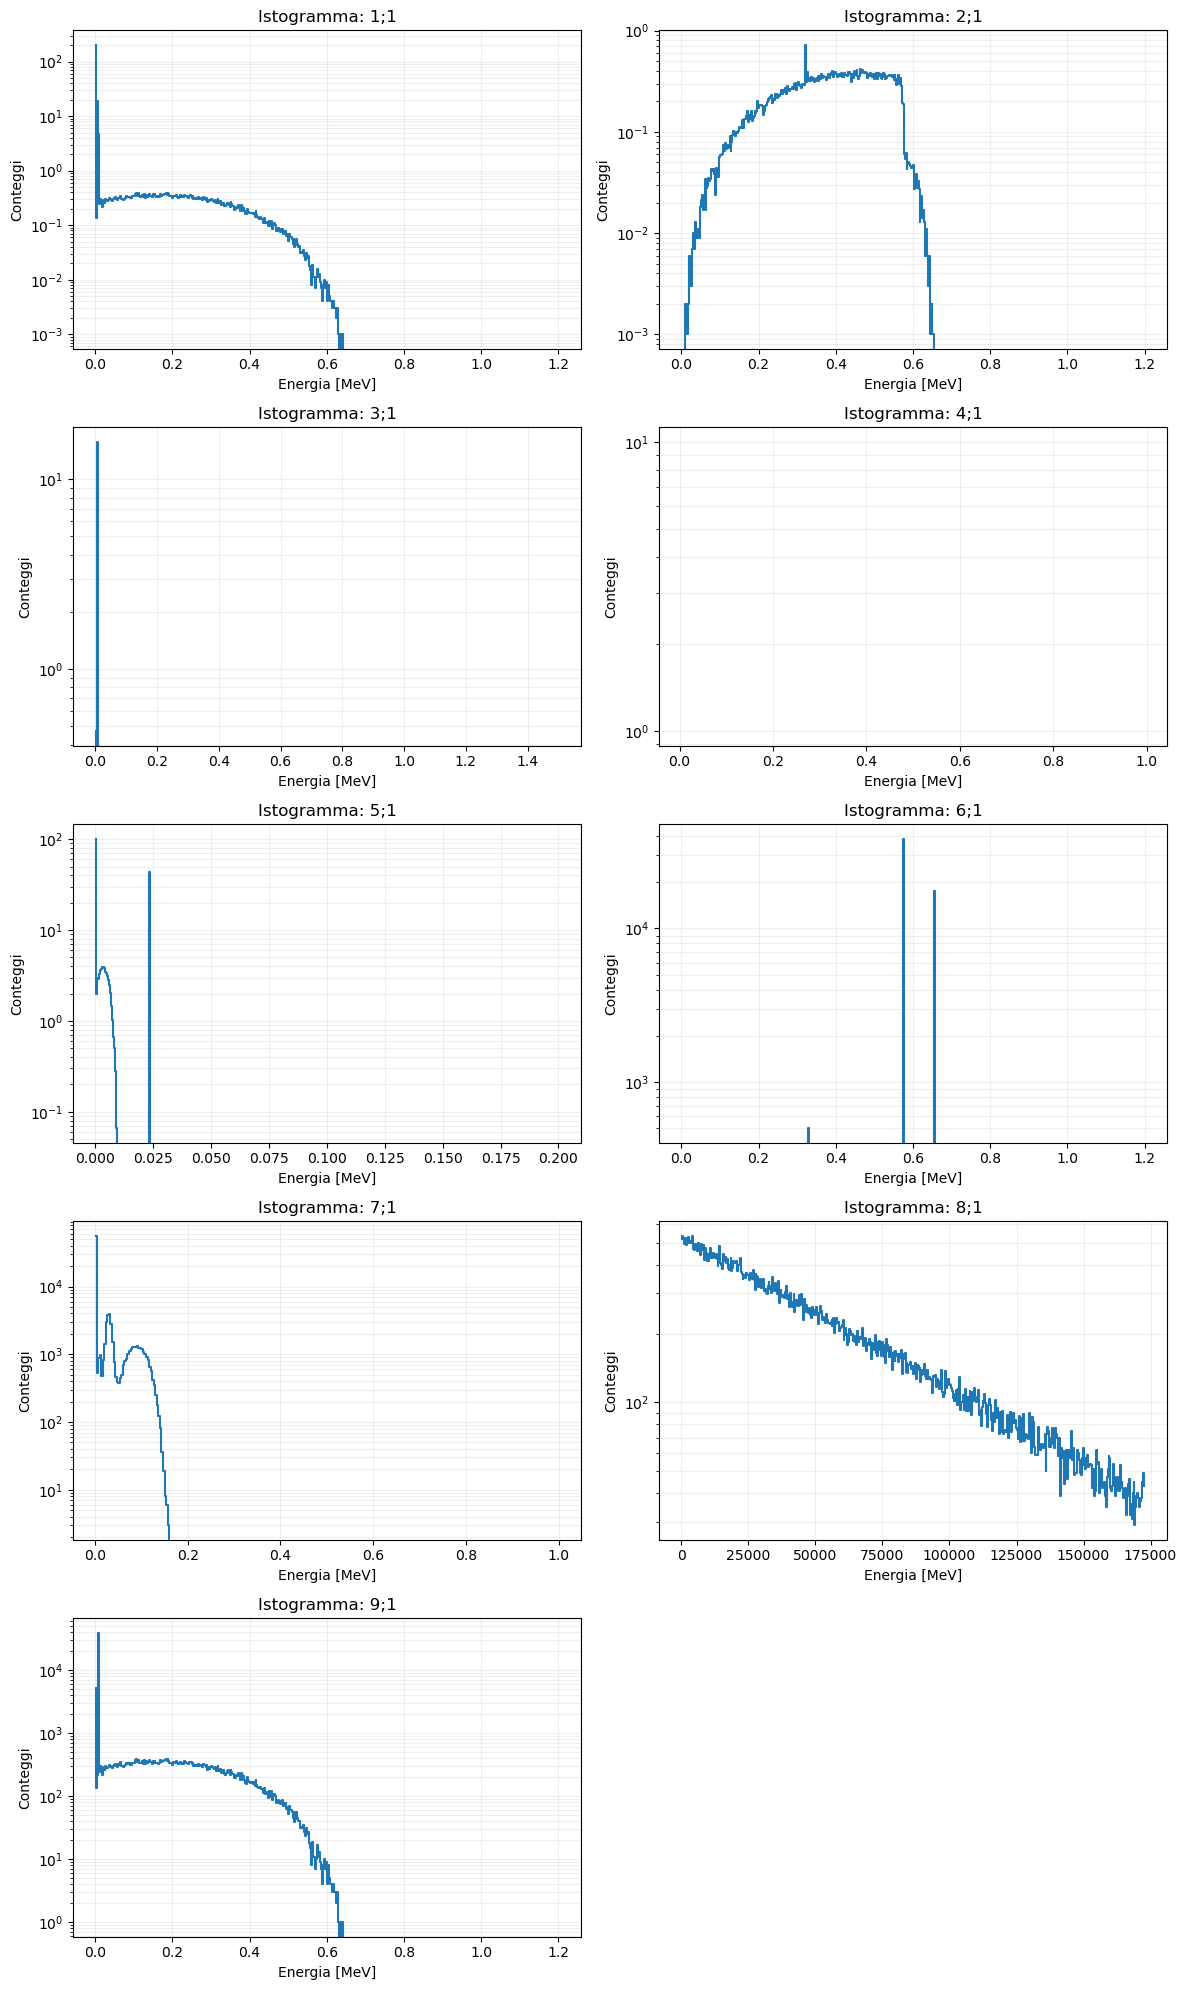

In [ ]:
import uproot
import matplotlib.pyplot as plt
import math

file_path = "../build/Cu64_output.root"

# Definiamo le etichette per ogni istogramma
# Chiave: nome nel file root, Valore: (Label X, Label Y, Titolo)
labels_map = {
    "1;1": ("Energia e+/e- [MeV]", "Conteggi", "Spettro Beta"),
    "2;1": ("Energia Neutrini [MeV]", "Conteggi", "Spettro Neutrini"),
    "3;1": ("Energia Gamma [MeV]", "Conteggi", "Spettro Gamma"),
    "4;1": ("Energia Alpha [MeV]", "Conteggi", "Spettro Alpha"),
    "5;1": ("Energia Rinculo [keV]", "Conteggi", "Ioni di Rinculo"),
    "6;1": ("Energia Totale [MeV]", "Conteggi", "Energia Cinetica Totale"),
    "7;1": ("Bilancio Momento [MeV/c]", "Conteggi", "Bilancio Momento"),
    "8;1": ("Tempo [s]", "Conteggi", "Tempo di vita"),
    "9;1": ("Energia Totale Visibile [MeV]", "Conteggi", "Energia Visibile"),
}

try:
    with uproot.open(file_path) as file:
        hist_keys = [k for k in file.keys() if "TH1" in file[k].classname]
        
        n_hists = len(hist_keys)
        cols = 2
        rows = math.ceil(n_hists / cols)
        
        fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
        if n_hists == 1: axes = [axes]
        else: axes = axes.flatten()

        for i, key in enumerate(hist_keys):
            obj = file[key]
            counts, edges = obj.to_numpy()
            centers = (edges[:-1] + edges[1:]) / 2
            
            # Recuperiamo le label dal dizionario, o usiamo valori di default
            # key.split(';')[0] serve a pulire il nome da ";1" se necessario
            base_key = key.split(';')[0] + ";1" 
            x_lbl, y_lbl, title = labels_map.get(key, ("Energia [MeV]", "Conteggi", f"Istogramma {key}"))
            
            ax = axes[i]
            ax.step(centers, counts, where='mid')
            ax.set_yscale('log')
            ax.set_xlabel(x_lbl)
            ax.set_ylabel(y_lbl)
            ax.set_title(title)
            ax.grid(True, which="both", ls="-", alpha=0.2)
        
        plt.tight_layout()
        plt.show()

except Exception as e:
    print(f"Errore: {e}")